# Popularity-Based Recommendation Model

This notebook builds a popularity-based recommendation system.

Instead of understanding semantic meaning like CLIP, this model recommends products based on their popularity score.

The popularity score was generated during feature engineering using:

Popularity Score = Ratings × log(Number of Ratings + 1)

This model serves as a baseline for comparison with the CLIP recommendation system.

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
feature_store = pd.read_csv(
    "../data/processed/feature_store.csv"
)

feature_store.head()

,Unnamed: 0,name,main_category,sub_category,image,link,ratings,no_of_ratings,discount_price,actual_price,discount_percentage,price_bucket,category_popularity,subcategory_popularity,popularity_score
0,0,"Redmi 10 Power (Power Black, 8GB RAM, 128GB St...","tv, audio & cameras",All Electronics,https://m.media-amazon.com/images/I/81eM15lVcJ...,https://www.amazon.in/Redmi-Power-Black-128GB-...,4.0,965.0,10999.0,18999.0,42.107479,Luxury,9600,9600,27.492655
1,1,"OnePlus Nord CE 2 Lite 5G (Blue Tide, 6GB RAM,...","tv, audio & cameras",All Electronics,https://m.media-amazon.com/images/I/71AvQd3Vzq...,https://www.amazon.in/OnePlus-Nord-Lite-128GB-...,4.3,113956.0,18999.0,19999.0,5.000250,Luxury,9600,9600,50.067379
2,2,OnePlus Bullets Z2 Bluetooth Wireless in Ear E...,"tv, audio & cameras",All Electronics,https://m.media-amazon.com/images/I/51UhwaQXCp...,https://www.amazon.in/Oneplus-Bluetooth-Wirele...,4.2,90304.0,1999.0,2299.0,13.049152,Medium,9600,9600,47.925982
3,3,"Samsung Galaxy M33 5G (Mystique Green, 6GB, 12...","tv, audio & cameras",All Electronics,https://m.media-amazon.com/images/I/81I3w4J6yj...,https://www.amazon.in/Samsung-Mystique-Storage...,4.1,24863.0,15999.0,24999.0,36.001440,Luxury,9600,9600,41.496823
4,4,"OnePlus Nord CE 2 Lite 5G (Black Dusk, 6GB RAM...","tv, audio & cameras",All Electronics,https://m.media-amazon.com/images/I/71V--WZVUI...,https://www.amazon.in/OnePlus-Nord-Black-128GB...,4.3,113956.0,18999.0,19999.0,5.000250,Luxury,9600,9600,50.067379


In [3]:
print(feature_store.shape)

feature_store.info()

(9600, 15)
<class 'pandas.DataFrame'>
RangeIndex: 9600 entries, 0 to 9599
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              9600 non-null   int64  
 1   name                    9600 non-null   str    
 2   main_category           9600 non-null   str    
 3   sub_category            9600 non-null   str    
 4   image                   9600 non-null   str    
 5   link                    9600 non-null   str    
 6   ratings                 9481 non-null   float64
 7   no_of_ratings           9481 non-null   float64
 8   discount_price          9116 non-null   float64
 9   actual_price            9530 non-null   float64
 10  discount_percentage     9600 non-null   float64
 11  price_bucket            9116 non-null   str    
 12  category_popularity     9600 non-null   int64  
 13  subcategory_popularity  9600 non-null   int64  
 14  popularity_score        9600 non-null   

In [4]:
top_products = feature_store.sort_values(
    by="popularity_score",
    ascending=False
)

top_products.head(10)

,Unnamed: 0,name,main_category,sub_category,image,link,ratings,no_of_ratings,discount_price,actual_price,discount_percentage,price_bucket,category_popularity,subcategory_popularity,popularity_score
8013,8013,AmazonBasics AA Performance Alkaline Non-Recha...,"tv, audio & cameras",All Electronics,https://m.media-amazon.com/images/I/81ZnAYiX5s...,https://www.amazon.in/AmazonBasics-Performance...,4.5,336487.0,929.0,1495.0,37.859532,Low,9600,9600,57.268430
7234,7234,AmazonBasics AA Performance Alkaline Non-Recha...,"tv, audio & cameras",All Electronics,https://m.media-amazon.com/images/I/81ZnAYiX5s...,https://www.amazon.in/AmazonBasics-Performance...,4.5,336487.0,929.0,1495.0,37.859532,Low,9600,9600,57.268430
470,470,Amazon Basics High-Speed HDMI Cable - 10 Feet ...,"tv, audio & cameras",All Electronics,https://m.media-amazon.com/images/I/61GUctqz0-...,https://www.amazon.in/AmazonBasics-High-Speed-...,4.4,437651.0,379.0,995.0,61.909548,Budget,9600,9600,57.152389
2542,2542,"Amazon Basics High-Speed HDMI Cable, 6 Feet (2...","tv, audio & cameras",All Electronics,https://m.media-amazon.com/images/I/61ntykhzGV...,https://www.amazon.in/AmazonBasics-High-Speed-...,4.4,437651.0,349.0,1400.0,75.071429,Budget,9600,9600,57.152389
1217,1217,"Amazon Basics High-Speed HDMI Cable, 6 Feet - ...","tv, audio & cameras",All Electronics,https://m.media-amazon.com/images/I/61pBvlYVPx...,https://www.amazon.in/AmazonBasics-High-Speed-...,4.4,437651.0,269.0,475.0,43.368421,Budget,9600,9600,57.152389
605,605,Amazon Basics Flexible Premium HDMI Cable (Bla...,"tv, audio & cameras",All Electronics,https://m.media-amazon.com/images/I/71gEiWJNPe...,https://www.amazon.in/AmazonBasics-Flexible-HD...,4.4,437651.0,269.0,700.0,61.571429,Budget,9600,9600,57.152389
4916,4916,AmazonBasics AAA Performance Alkaline Non-rech...,"tv, audio & cameras",All Electronics,https://m.media-amazon.com/images/I/81F7OfBTCv...,https://www.amazon.in/AmazonBasics-Performance...,4.4,351441.0,639.0,900.0,29.000000,Low,9600,9600,56.187120
1497,1497,SanDisk Extreme Pro SD UHS I 128GB Card for 4K...,"tv, audio & cameras",All Electronics,https://m.media-amazon.com/images/I/81wwLOgkLg...,https://www.amazon.in/SanDisk-Extreme-128GB-Mi...,4.5,215311.0,2108.0,5300.0,60.226415,Medium,9600,9600,55.259295
5711,5711,SanDisk Extreme SD UHS I 32GB Card for 4K Vide...,"tv, audio & cameras",All Electronics,https://m.media-amazon.com/images/I/81Azm8B5u5...,https://www.amazon.in/SanDisk-Extreme-Video-Mi...,4.5,215311.0,599.0,1200.0,50.083333,Low,9600,9600,55.259295
1408,1408,SanDisk Extreme SD UHS I 128GB Card for 4K Vid...,"tv, audio & cameras",All Electronics,https://m.media-amazon.com/images/I/81Rivcu2p4...,https://www.amazon.in/SanDisk-Extreme-128GB-Mi...,4.5,215311.0,1529.0,3700.0,58.675676,Medium,9600,9600,55.259295


In [5]:
top_products[
    [
        "name",
        "ratings",
        "no_of_ratings",
        "discount_price",
        "popularity_score"
    ]
].head(10)

,name,ratings,no_of_ratings,discount_price,popularity_score
8013,AmazonBasics AA Performance Alkaline Non-Recha...,4.5,336487.0,929.0,57.268430
7234,AmazonBasics AA Performance Alkaline Non-Recha...,4.5,336487.0,929.0,57.268430
470,Amazon Basics High-Speed HDMI Cable - 10 Feet ...,4.4,437651.0,379.0,57.152389
2542,"Amazon Basics High-Speed HDMI Cable, 6 Feet (2...",4.4,437651.0,349.0,57.152389
1217,"Amazon Basics High-Speed HDMI Cable, 6 Feet - ...",4.4,437651.0,269.0,57.152389
605,Amazon Basics Flexible Premium HDMI Cable (Bla...,4.4,437651.0,269.0,57.152389
4916,AmazonBasics AAA Performance Alkaline Non-rech...,4.4,351441.0,639.0,56.187120
1497,SanDisk Extreme Pro SD UHS I 128GB Card for 4K...,4.5,215311.0,2108.0,55.259295
5711,SanDisk Extreme SD UHS I 32GB Card for 4K Vide...,4.5,215311.0,599.0,55.259295
1408,SanDisk Extreme SD UHS I 128GB Card for 4K Vid...,4.5,215311.0,1529.0,55.259295


In [6]:
def recommend_popular_products(top_k=10):

    recommendations = (
        feature_store
        .sort_values(
            by="popularity_score",
            ascending=False
        )
        .head(top_k)
    )

    return recommendations

In [7]:
popular = recommend_popular_products()

popular[
    [
        "name",
        "ratings",
        "no_of_ratings",
        "discount_price",
        "popularity_score"
    ]
]

,name,ratings,no_of_ratings,discount_price,popularity_score
8013,AmazonBasics AA Performance Alkaline Non-Recha...,4.5,336487.0,929.0,57.268430
7234,AmazonBasics AA Performance Alkaline Non-Recha...,4.5,336487.0,929.0,57.268430
470,Amazon Basics High-Speed HDMI Cable - 10 Feet ...,4.4,437651.0,379.0,57.152389
2542,"Amazon Basics High-Speed HDMI Cable, 6 Feet (2...",4.4,437651.0,349.0,57.152389
1217,"Amazon Basics High-Speed HDMI Cable, 6 Feet - ...",4.4,437651.0,269.0,57.152389
605,Amazon Basics Flexible Premium HDMI Cable (Bla...,4.4,437651.0,269.0,57.152389
4916,AmazonBasics AAA Performance Alkaline Non-rech...,4.4,351441.0,639.0,56.187120
1497,SanDisk Extreme Pro SD UHS I 128GB Card for 4K...,4.5,215311.0,2108.0,55.259295
5711,SanDisk Extreme SD UHS I 32GB Card for 4K Vide...,4.5,215311.0,599.0,55.259295
1408,SanDisk Extreme SD UHS I 128GB Card for 4K Vid...,4.5,215311.0,1529.0,55.259295


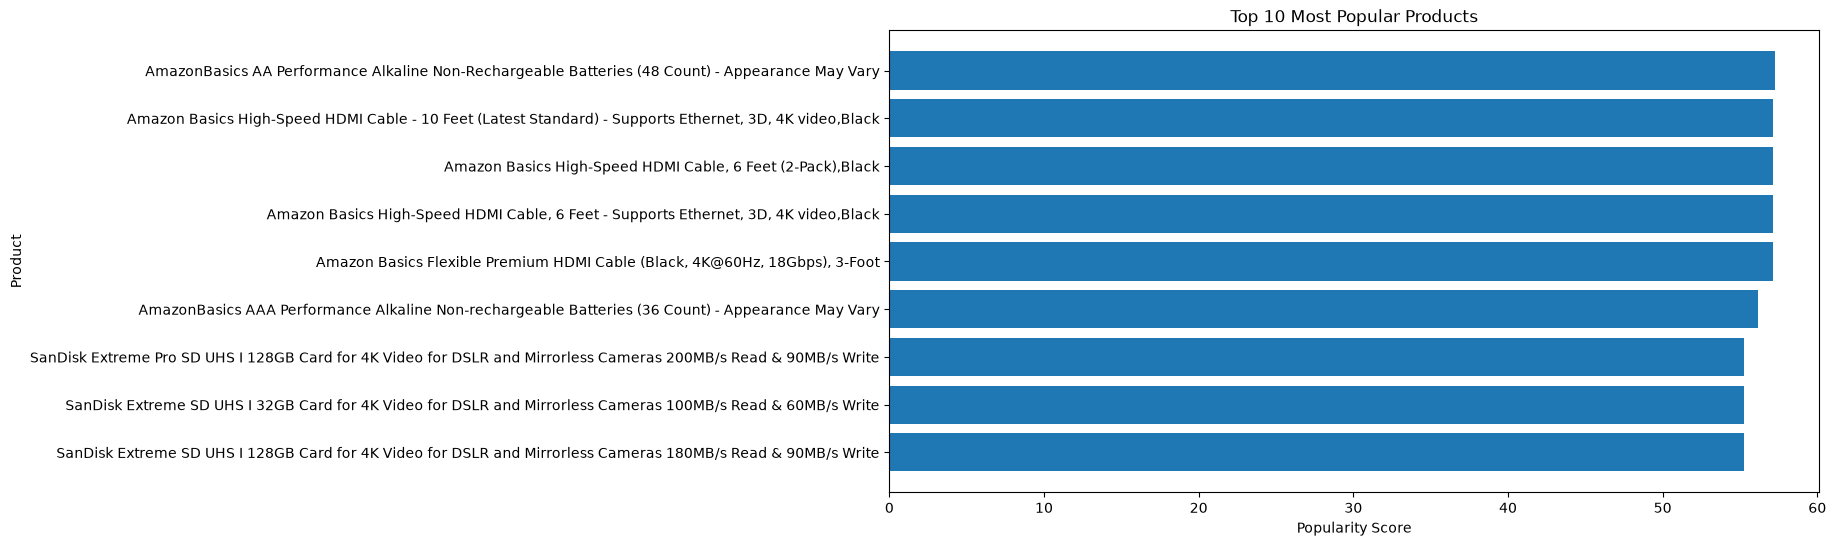

In [8]:
top10 = recommend_popular_products()

plt.figure(figsize=(12,6))

plt.barh(
    top10["name"],
    top10["popularity_score"]
)

plt.xlabel("Popularity Score")

plt.ylabel("Product")

plt.title("Top 10 Most Popular Products")

plt.gca().invert_yaxis()

plt.show()

In [9]:
feature_store["main_category"].value_counts()

main_category
tv, audio & cameras    9600
Name: count, dtype: int64

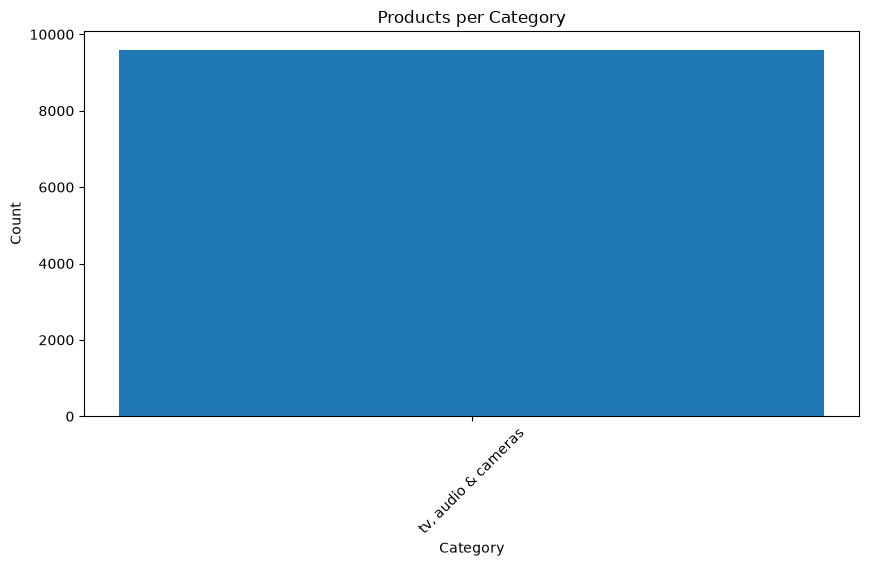

In [10]:
category_counts = (
    feature_store["main_category"]
    .value_counts()
)

plt.figure(figsize=(10,5))

plt.bar(
    category_counts.index,
    category_counts.values
)

plt.xticks(rotation=45)

plt.title("Products per Category")

plt.xlabel("Category")

plt.ylabel("Count")

plt.show()

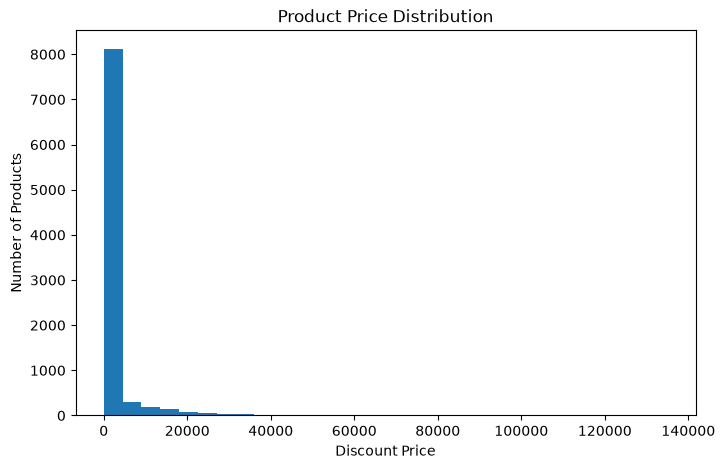

In [11]:
plt.figure(figsize=(8,5))

plt.hist(
    feature_store["discount_price"].dropna(),
    bins=30
)

plt.xlabel("Discount Price")

plt.ylabel("Number of Products")

plt.title("Product Price Distribution")

plt.show()

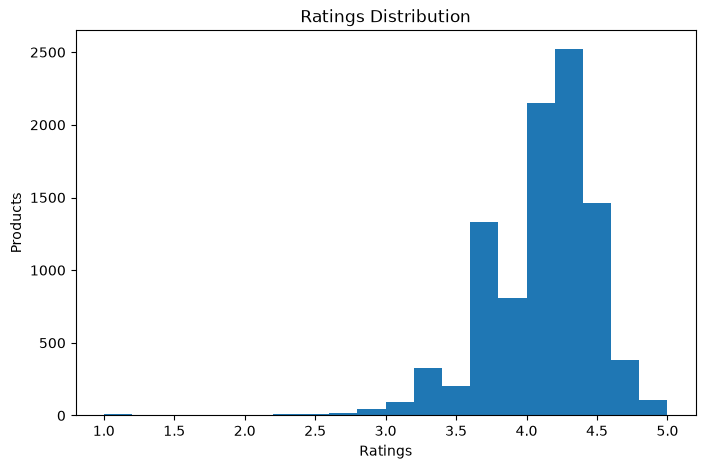

In [12]:
plt.figure(figsize=(8,5))

plt.hist(
    feature_store["ratings"].dropna(),
    bins=20
)

plt.xlabel("Ratings")

plt.ylabel("Products")

plt.title("Ratings Distribution")

plt.show()

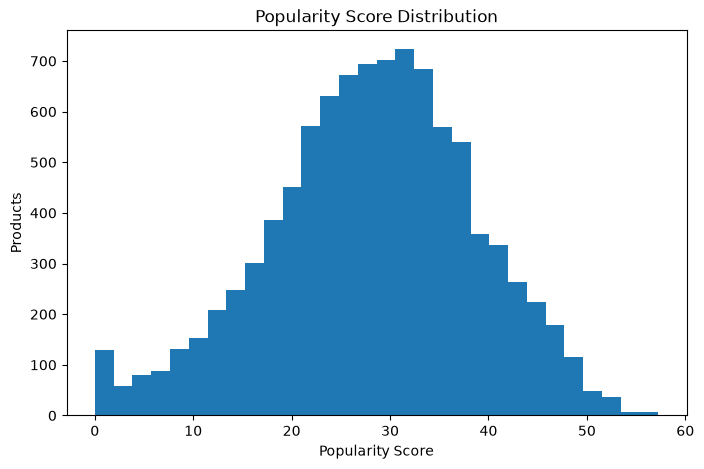

In [13]:
plt.figure(figsize=(8,5))

plt.hist(
    feature_store["popularity_score"].dropna(),
    bins=30
)

plt.xlabel("Popularity Score")

plt.ylabel("Products")

plt.title("Popularity Score Distribution")

plt.show()

In [14]:
recommend_popular_products().to_csv(

    "../data/processed/popular_products.csv",

    index=False
)

print("Top Popular Products Saved Successfully!")

Top Popular Products Saved Successfully!


In [15]:
popular = pd.read_csv(
    "../data/processed/popular_products.csv"
)

popular.head()

,Unnamed: 0,name,main_category,sub_category,image,link,ratings,no_of_ratings,discount_price,actual_price,discount_percentage,price_bucket,category_popularity,subcategory_popularity,popularity_score
0,8013,AmazonBasics AA Performance Alkaline Non-Recha...,"tv, audio & cameras",All Electronics,https://m.media-amazon.com/images/I/81ZnAYiX5s...,https://www.amazon.in/AmazonBasics-Performance...,4.5,336487.0,929.0,1495.0,37.859532,Low,9600,9600,57.268430
1,7234,AmazonBasics AA Performance Alkaline Non-Recha...,"tv, audio & cameras",All Electronics,https://m.media-amazon.com/images/I/81ZnAYiX5s...,https://www.amazon.in/AmazonBasics-Performance...,4.5,336487.0,929.0,1495.0,37.859532,Low,9600,9600,57.268430
2,470,Amazon Basics High-Speed HDMI Cable - 10 Feet ...,"tv, audio & cameras",All Electronics,https://m.media-amazon.com/images/I/61GUctqz0-...,https://www.amazon.in/AmazonBasics-High-Speed-...,4.4,437651.0,379.0,995.0,61.909548,Budget,9600,9600,57.152389
3,2542,"Amazon Basics High-Speed HDMI Cable, 6 Feet (2...","tv, audio & cameras",All Electronics,https://m.media-amazon.com/images/I/61ntykhzGV...,https://www.amazon.in/AmazonBasics-High-Speed-...,4.4,437651.0,349.0,1400.0,75.071429,Budget,9600,9600,57.152389
4,1217,"Amazon Basics High-Speed HDMI Cable, 6 Feet - ...","tv, audio & cameras",All Electronics,https://m.media-amazon.com/images/I/61pBvlYVPx...,https://www.amazon.in/AmazonBasics-High-Speed-...,4.4,437651.0,269.0,475.0,43.368421,Budget,9600,9600,57.152389


# Conclusion

The popularity-based recommendation model recommends products with the highest popularity scores.

Advantages:
- Simple
- Fast
- No machine learning required
- Useful for new users (cold start)

Limitations:
- Same recommendations for every user
- No personalization
- Cannot understand semantic similarity

This model serves as a baseline for comparison with the CLIP-based recommendation system.